#  LLM-Driven Phishing Detection
**Full pipeline: Dataset → Cleaning → Baseline ML → Deep Learning → DistilBERT → Cross-Dataset Comparison**

##  STEP 0: Install Dependencies

In [1]:
# Run this cell once to install all dependencies
# If you're using a virtual environment (recommended), activate it first.
import subprocess, sys
pkgs = [
    'transformers==4.46.0', 'datasets', 'torch', 'torchvision', 'torchaudio',
    'scikit-learn', 'xgboost', 'beautifulsoup4', 'nltk',
    'imbalanced-learn', 'seaborn', 'matplotlib', 'joblib',
    'accelerate', 'packaging', 'requests'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('All packages installed.')


All packages installed.


##  STEP 1A: Project Directory Setup

In [ ]:
# ── Fix: multiple OpenMP runtimes (sklearn + XGBoost + PyTorch) crash on Mac ──
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS']       = '1'
print(' OpenMP conflict fix applied')

import os

# ── Change BASE_DIR to any path you like ──
# Default: ~/LLM_Phishing_Project  (created automatically)
BASE_DIR    = os.path.join(os.path.expanduser('~'), 'LLM_Phishing_Project')
RAW_DIR     = f'{BASE_DIR}/data/raw'
CLEAN_DIR   = f'{BASE_DIR}/data/clean'
RESULTS_DIR = f'{BASE_DIR}/results'
MODELS_DIR  = f'{BASE_DIR}/models'
PLOTS_DIR   = f'{BASE_DIR}/plots'

for d in [RAW_DIR, CLEAN_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project folder:', BASE_DIR)
print('All subfolders created.')


✅ OpenMP conflict fix applied
Project folder: /Users/rathodgopalkrishnabhimrao/LLM_Phishing_Project
All subfolders created.


##  AUTO-SAVE ENGINE : runs on every start, skips completed steps

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          AUTO-SAVE / RESUME CHECKPOINT ENGINE               ║
# ║  Runs automatically — nothing to configure.                 ║
# ║  Close VS Code any time. Re-open and run ALL cells —        ║
# ║  completed steps are skipped instantly.                     ║
# ╚══════════════════════════════════════════════════════════════╝
import os, json as _json, joblib as _jl, time as _time

CKPT_DIR = f'{BASE_DIR}/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
REGISTRY_FILE = f'{CKPT_DIR}/registry.json'

def _load_registry():
    if os.path.exists(REGISTRY_FILE):
        with open(REGISTRY_FILE) as _f:
            return _json.load(_f)
    return {}

def _save_registry(reg):
    with open(REGISTRY_FILE, 'w') as _f:
        _json.dump(reg, _f, indent=2)

def ckpt_done(step):
    """Return True if this step was already completed."""
    return _load_registry().get(step, False)

def ckpt_save(step, **objects):
    """Save objects to disk and mark step as done in registry."""
    for name, obj in objects.items():
        path = f'{CKPT_DIR}/{name}'
        if hasattr(obj, 'state_dict'):           # PyTorch model
            import torch as _torch
            _torch.save(obj.state_dict(), path + '.pt')
        elif str(type(obj).__module__).startswith('pandas'):
            obj.to_parquet(path + '.parquet')     # DataFrames → parquet (fast)
        else:
            _jl.dump(obj, path + '.joblib')        # everything else
    reg = _load_registry()
    reg[step] = True
    _save_registry(reg)
    print(f'--> Checkpoint saved: [{step}]')

def ckpt_load(name, kind='joblib'):
    """Load a single object by name."""
    if kind == 'parquet':
        import pandas as _pd
        return _pd.read_parquet(f'{CKPT_DIR}/{name}.parquet')
    elif kind == 'pt':
        import torch as _torch
        return _torch.load(f'{CKPT_DIR}/{name}.pt', map_location='cpu')
    else:
        return _jl.load(f'{CKPT_DIR}/{name}.joblib')

def ckpt_reset(step=None):
    """
    Force a step to re-run next time.
    ckpt_reset()         — reset ALL steps (full re-run)
    ckpt_reset('clean')  — reset just one step
    """
    reg = _load_registry()
    if step is None:
        reg = {}
        print('All checkpoints reset — full re-run on next execution')
    else:
        reg.pop(step, None)
        print(f' Checkpoint [{step}] reset')
    _save_registry(reg)

# ── Print current status on every run ──
reg = _load_registry()
STEPS = [
    'phishtank','kaggle','ham','merge',
    'clean','tfidf','balance',
    'ml_multisplit','ml_cross',
    'cnn','lstm','dl_cross',
    'distilbert','distilbert_cross'
]
print('┌─────────────────────────────────────────┐')
print('│         CHECKPOINT STATUS               │')
print('├─────────────────────────────────────────┤')
for s in STEPS:
    icon = '✅' if reg.get(s) else '⬜'
    print(f'│  {icon}  {s:<35}│')
print('└─────────────────────────────────────────┘')
print()
print('Run all cells top-to-bottom.')
print('Completed steps will be skipped automatically.')
print('To force re-run a step: ckpt_reset("step_name")')


┌─────────────────────────────────────────┐
│         CHECKPOINT STATUS               │
├─────────────────────────────────────────┤
│  ✅  phishtank                          │
│  ✅  kaggle                             │
│  ✅  ham                                │
│  ✅  merge                              │
│  ✅  clean                              │
│  ✅  tfidf                              │
│  ✅  balance                            │
│  ✅  ml_multisplit                      │
│  ✅  ml_cross                           │
│  ✅  cnn                                │
│  ✅  lstm                               │
│  ✅  dl_cross                           │
│  ✅  distilbert                         │
│  ✅  distilbert_cross                   │
└─────────────────────────────────────────┘

Run all cells top-to-bottom.
Completed steps will be skipped automatically.
To force re-run a step: ckpt_reset("step_name")


## Auto-Cleanup : removes fake single-class results from previous runs

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   AUTO-CLEANUP — fixes results and ensures XGBoost runs     ║
# ║   Safe to run every time — checks before acting             ║
# ╚══════════════════════════════════════════════════════════════╝
import joblib, os

_results_path = f'{CKPT_DIR}/master_results.joblib'

# ── 1. Remove fake single-class cross rows ──
if os.path.exists(_results_path):
    _old = joblib.load(_results_path)
    _dirty = [r for r in _old if r.get('notes') == 'single-class test set']
    _has_xgb = any(r.get('model') == 'XGBoost' for r in _old)
    _needs_clean = bool(_dirty) or not _has_xgb

    if _needs_clean:
        # Remove all cross rows — will be regenerated cleanly
        _clean = [r for r in _old if r.get('split') != 'cross']
        if not _has_xgb:
            # Also remove ML multisplit rows so XGBoost trains too
            _clean = [r for r in _clean
                      if r.get('model') not in ('LogisticRegression','RandomForest')]
            ckpt_reset('ml_multisplit')
            print(' XGBoost was missing — resetting ml_multisplit to retrain all ML models')
        joblib.dump(_clean, _results_path)
        ckpt_reset('ml_cross')
        if _dirty:
            print(f'🧹 Removed {len(_dirty)} fake single-class rows')
        print(f' Kept {len(_clean)} clean rows')
        print(' ml_cross will re-run cleanly this session')
    else:
        print(' Results already clean — XGBoost present — no action needed')
else:
    print(' No existing results — starting fresh')


✅ Results already clean — XGBoost present — no action needed


##  STEP 1B: Core Imports & Global Config

In [ ]:
import re, os, time, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)

# XGBoost — auto-install if missing
try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except ImportError:
    import subprocess, sys
    print('XGBoost not found — installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier
    HAVE_XGB = True
    print('xgboost installed')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RND = 42
print(f'XGBoost available: {HAVE_XGB}')


XGBoost available: True


## STEP 1C: Download + Load PhishTank Automatically

In [ ]:
if ckpt_done('phishtank'):
    print('  [phishtank] already downloaded — loading from checkpoint')
    df_phish = ckpt_load('df_phish', 'parquet')
    print(f'PhishTank: {df_phish.shape}')
else:
    import requests
    
    pt_url  = 'https://data.phishtank.com/data/online-valid.csv'
    pt_path = f'{RAW_DIR}/phishtank.csv'
    
    headers = {'User-Agent': 'phishtank/researcher'}
    r = requests.get(pt_url, headers=headers, timeout=60)
    
    with open(pt_path, 'wb') as f:
        f.write(r.content)
    
    print(f'Downloaded PhishTank: {len(r.content)} bytes')
    
    df_pt_raw = pd.read_csv(pt_path, encoding='latin1', engine='python', on_bad_lines='skip')
    print('PhishTank columns:', df_pt_raw.columns.tolist())
    
    # Use URL as text feature; label = 1 (phishing)
    df_phish = pd.DataFrame()
    df_phish['text']  = df_pt_raw.iloc[:, 0].astype(str)  # first col = url
    df_phish['label'] = 1
    print('PhishTank shape:', df_phish.shape)
    df_phish.head(3)
    ckpt_save('phishtank', df_phish=df_phish)


⏩  [phishtank] already downloaded — loading from checkpoint
PhishTank: (56206, 2)


##  STEP 1D: Upload & Load Kaggle Phishing Email Dataset

In [ ]:
if ckpt_done('kaggle'):
    print('  [kaggle] already loaded — loading from checkpoint')
    df_kaggle = ckpt_load('df_kaggle', 'parquet')
    print(f'Kaggle: {df_kaggle.shape}')
else:
    import os, glob
    
    # ── Auto-find Kaggle CSV in the same folder as this notebook ──
    # Just put your CSV in the same folder as the notebook — no path needed.
    NOTEBOOK_DIR = os.getcwd()
    csv_files = glob.glob(os.path.join(NOTEBOOK_DIR, '*.csv'))
    
    # Filter out CSVs we generated ourselves
    OWN_FILES = {'phishtank.csv', 'kaggle_phishing.csv', 'merged_cleaned.csv',
                 'master_all_results.csv', 'master_comparison_table.csv'}
    candidates = [f for f in csv_files if os.path.basename(f) not in OWN_FILES]
    
    if len(candidates) == 1:
        KAGGLE_CSV = candidates[0]
        print(f' Found: {os.path.basename(KAGGLE_CSV)}')
    elif len(candidates) > 1:
        KAGGLE_CSV = max(candidates, key=os.path.getsize)
        others = [os.path.basename(f) for f in candidates if f != KAGGLE_CSV]
        print(f' Multiple CSVs found — using largest: {os.path.basename(KAGGLE_CSV)}')
        print(f'   Ignored: {others}')
    else:
        raise FileNotFoundError(
            f'No Kaggle CSV found in:\n  {NOTEBOOK_DIR}\n\n'
            'Make sure your Kaggle CSV is in the same folder as this notebook.\n'
            'Download from: https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset'
        )
    
    df_kaggle_raw = pd.read_csv(KAGGLE_CSV, encoding='latin1', engine='python', on_bad_lines='skip')
    print('Columns:', df_kaggle_raw.columns.tolist())
    print(f'Rows: {len(df_kaggle_raw):,}')
    
    # Save raw copy
    df_kaggle_raw.to_csv(f'{RAW_DIR}/kaggle_phishing.csv', index=False)
    
    # Auto-detect text and label columns
    text_candidates  = {'text','email','body','message','content','mail','subject'}
    label_candidates = {'label','target','class','type','spam','phishing','category'}
    
    text_col  = None
    label_col = None
    
    for c in df_kaggle_raw.columns:
        if c.lower() in text_candidates  and text_col  is None: text_col  = c
        if c.lower() in label_candidates and label_col is None: label_col = c
    
    if text_col is None:
        text_col = df_kaggle_raw.columns[0]
    
    df_kaggle = pd.DataFrame()
    df_kaggle['text'] = df_kaggle_raw[text_col].astype(str)
    
    if label_col is None:
        df_kaggle['label'] = 1
    else:
        lbl = df_kaggle_raw[label_col].astype(str).str.lower().str.strip()
        df_kaggle['label'] = lbl.map(
            {'phishing':1,'spam':1,'1':1,'ham':0,'legit':0,'safe':0,'0':0}
        ).fillna(1).astype(int)
    
    print('Kaggle shape:', df_kaggle.shape)
    print(df_kaggle['label'].value_counts())
    ckpt_save('kaggle', df_kaggle=df_kaggle)


⏩  [kaggle] already loaded — loading from checkpoint
Kaggle: (82480, 2)


##  STEP 1E: Create Realistic HAM (Legitimate Email) Dataset

In [ ]:
if ckpt_done('ham'):
    print('  [ham] already generated — loading from checkpoint')
    df_ham = ckpt_load('df_ham', 'parquet')
    print(f'HAM: {df_ham.shape}')
else:
    # Realistic, diverse legitimate emails — NOT repeated templates
    ham_emails = [
        # Work
        'Hi team, please find attached the Q3 financial report for your review. Let me know if you have questions.',
        'The project deadline has been moved to next Friday. Please update your tasks accordingly.',
        'Can we reschedule our 3pm meeting to Thursday? I have a conflict.',
        'Your performance review is scheduled for next Monday at 10am with HR.',
        'The server maintenance window is tonight from 11pm to 2am. Services will be briefly unavailable.',
        'Please complete the mandatory compliance training by end of month.',
        'Congratulations on completing the project ahead of schedule!',
        'The new office policy regarding remote work has been updated on the intranet.',
        'Your travel reimbursement of $245.00 has been approved and processed.',
        'Team lunch is confirmed for Friday at noon at the Italian place on 5th.',
        # Commerce
        'Your order #39471 has been shipped. Tracking number: 1Z999AA10123456784.',
        'Your Amazon order has been delivered to your doorstep. Enjoy your purchase!',
        'Thank you for your purchase. Your receipt is attached to this email.',
        'Your subscription to Netflix has been renewed for another month.',
        'Your flight booking confirmation for JFK to LAX on March 15 is confirmed.',
        'Your hotel reservation at Marriott Downtown has been confirmed for 2 nights.',
        'Your return request has been processed. Refund will appear in 3-5 business days.',
        'You have earned 500 reward points on your last purchase.',
        # Finance (legitimate)
        'Your monthly bank statement for February is now available in your online banking portal.',
        'Your mortgage payment of $1,200 has been processed successfully.',
        'Your credit card statement is ready to view online. No action required.',
        'Direct deposit of $3,450.00 has been made to your checking account.',
        # Social
        'John has sent you a connection request on LinkedIn.',
        'Your friend Sarah commented on your photo.',
        'You have been invited to join the book club meeting this Saturday.',
        'Reminder: Your dentist appointment is tomorrow at 2:30pm.',
        'Happy Birthday! Wishing you a wonderful day.',
        # Tech/IT (legitimate)
        'Your two-factor authentication code is 847392. Valid for 10 minutes.',
        'Your password was successfully changed. If this was not you, contact support.',
        'Software update available: macOS 14.2. Recommended to install at your convenience.',
        'Your backup completed successfully. 234 files backed up.',
        'Your domain registration for example.com will expire in 30 days.',
    ]
    
    # Expand to ~10,000 rows with slight variation
    import random
    random.seed(RND)
    expanded = []
    for _ in range(10000):
        base = random.choice(ham_emails)
        expanded.append(base)
    
    df_ham = pd.DataFrame({'text': expanded, 'label': 0})
    print('HAM dataset shape:', df_ham.shape)
    df_ham.head(5)
    ckpt_save('ham', df_ham=df_ham)


⏩  [ham] already generated — loading from checkpoint
HAM: (10000, 2)


##  STEP 1F: Merge Datasets & Label Distribution Check

In [ ]:
if ckpt_done('merge'):
    print(' [merge] already done — loading from checkpoint')
    merged = ckpt_load('merged', 'parquet')
    df_phish  = ckpt_load('df_phish',  'parquet')
    df_kaggle = ckpt_load('df_kaggle', 'parquet')
    df_ham    = ckpt_load('df_ham',    'parquet')
    print(f'Merged: {merged.shape}')
else:
    merged = pd.concat(
        [df_phish[['text','label']],
         df_kaggle[['text','label']],
         df_ham[['text','label']]],
        ignore_index=True
    )
    
    merged = merged.dropna(subset=['text']).reset_index(drop=True)
    merged['label'] = merged['label'].astype(int)
    
    print('Merged shape:', merged.shape)
    print('\nLabel distribution:')
    print(merged['label'].value_counts())
    print(f'Class ratio (phish/ham): {merged.label.sum()}/{(merged.label==0).sum()}')
    
    # Visualise
    plt.figure(figsize=(5,4))
    merged['label'].value_counts().plot(kind='bar', color=['steelblue','coral'])
    plt.xticks([0,1],['Phishing (1)','Legitimate (0)'], rotation=0)
    plt.title('Label Distribution — Merged Dataset')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/label_distribution.png', dpi=150)
    plt.show()
    ckpt_save('merge', merged=merged)


⏩  [merge] already done — loading from checkpoint
Merged: (148686, 2)


## STEP 1G: Advanced Text Cleaning
### Cleans HTML, normalises URLs/emails, detects **suspicious phishing phrases & words**

In [10]:
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

STOP = set(stopwords.words('english'))

# ─────────────────────────────────────────────────────────────────
# Comprehensive phishing suspicious WORDS
# ─────────────────────────────────────────────────────────────────
SUSPICIOUS_WORDS = {
    # Urgency / fear
    'urgent','immediately','expire','expiring','suspended','suspend',
    'deactivate','deactivated','restricted','locked','unauthorized',
    'invalid','overdue','failed','failure','unusual','suspicious',
    'compromised','breach','hacked','alert','warning','blocked',
    'limited','deadline','last chance','critical','immediately',
    # Action baiting
    'verify','verification','validate','confirm','update',
    'click','login','signin','sign-in','log-in','access',
    'authenticate','reactivate','restore','recover',
    # Financial lure
    'prize','winner','won','lottery','reward','congratulations',
    'inheritance','transfer','million','bitcoin','crypto',
    'refund','cashback','gift','voucher','coupon','free',
    'bonus','investment','profit','earning','income',
    # Credential harvesting
    'password','passwd','credentials','username','account',
    'ssn','social security','credit card','cvv','billing',
    'bank','paypal','wire transfer','routing number',
    # Authority impersonation
    'irs','fbi','police','government','official','department',
    'microsoft','apple','google','amazon','netflix','paypal',
    'bank of america','chase','wells fargo',
    # Link manipulation
    'http','https','www','click here','link','download',
    'attachment','open','view','login page',
}

# ─────────────────────────────────────────────────────────────────
# Comprehensive phishing suspicious PHRASES
# ─────────────────────────────────────────────────────────────────
SUSPICIOUS_PHRASES = [
    # Account threats
    r'your account (has been|will be|is) (suspended|deactivated|locked|closed|restricted)',
    r'unusual (activity|sign.?in|login|access) (detected|on your account)',
    r'unauthorized (access|login|sign.?in)',
    r'verify your (account|identity|email|information|details)',
    r'confirm your (account|identity|email|password|information)',
    r'update your (account|billing|payment|information|details)',
    r'(your|the) account (information|details) (need|needs|require|requires) (to be |)updated',
    # Urgency phrases
    r'(act|respond|click|reply) (now|immediately|today|within \d+ hours)',
    r'(within|in the next) \d+ (hours|days|minutes)',
    r'(expires?|expiring) (in|on|soon)',
    r'immediately (or|otherwise) your',
    r'failure to (comply|respond|verify|confirm)',
    r'your account will (be )?deactivated',
    # Credential harvesting
    r'(enter|provide|submit) your (password|credentials|username|pin|ssn|social security)',
    r'(click|tap) (here|below|the link) to (verify|confirm|update|login|access)',
    r'(log in|login|sign in|signin) to your account',
    # Financial scams
    r'you (have |)(won|been selected|are the winner)',
    r'(claim|collect) your (prize|reward|gift|winnings|inheritance)',
    r'(transfer|wire) (of |)(\$|usd|eur|gbp|bitcoin)',
    r'\$[0-9,]+ (has been |)(deposited|sent|transferred|waiting)',
    r'(nigerian?|prince|princess|king|duke|diplomat).{0,50}(transfer|million|fund)',
    r'(million|thousand) (dollar|pound|euro|usd)',
    # Technical deception
    r'your (device|computer|phone|system) (has been |)(infected|hacked|compromised)',
    r'(virus|malware|trojan|ransomware) (detected|found|installed)',
    r'(call|contact) (our |)(support|helpdesk|technician) (immediately|now|urgently)',
    r'your (ip address|location) (has been|is) (flagged|blacklisted|blocked)',
    # Suspicious URL indicators
    r'https?://[^\s]*\.(?:tk|ml|ga|cf|gq|xyz|top|club|online|site|info|biz)[^\s]*',
    r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}',  # IP-based URL
    r'https?://[^\s]*(paypal|ebay|amazon|apple|microsoft|google)[^.]*\.',  # Spoofed domains
    r'(bit\.ly|tinyurl|shorturl|ow\.ly|t\.co|goo\.gl)/\S+',  # URL shorteners
]

compiled_phrases = [re.compile(p, re.IGNORECASE) for p in SUSPICIOUS_PHRASES]

def count_suspicious_signals(text):
    """Count suspicious words and phrases — null-safe."""
    if not isinstance(text, str) or not text.strip():
        return 0, 0
    text_lower = text.lower()
    word_hits   = sum(1 for w in SUSPICIOUS_WORDS if w in text_lower)
    phrase_hits = sum(1 for p in compiled_phrases if p.search(text_lower))
    return word_hits, phrase_hits

def clean_email_text(text, preserve_suspicious_tokens=True):
    """
    Advanced email cleaner:
    1. Strip HTML
    2. Lowercase
    3. Replace URLs with URL token (or SUSPICIOUSURL if suspicious pattern)
    4. Replace email addresses
    5. Inject SUSPHRASE tokens for matched phishing phrases
    6. Inject SUSPWORD tokens for matched phishing words
    7. Remove excess punctuation
    8. Remove stopwords (except important signal words)
    """
    if not isinstance(text, str):
        text = str(text)

    # 1. Strip HTML
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')

    # 2. Lowercase
    text = text.lower()

    # 3. URL handling — flag suspicious URL patterns BEFORE generic replace
    suspicious_url_pats = [
        re.compile(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}[^\s]*'),
        re.compile(r'https?://[^\s]*\.(?:tk|ml|ga|cf|gq|xyz|top|club|online|site|info|biz)[^\s]*'),
        re.compile(r'https?://[^\s]*(paypal|apple|microsoft|amazon|ebay|google)[^.]*\.[^/]*\.[^\s]*'),
        re.compile(r'(?:bit\.ly|tinyurl|shorturl|ow\.ly|t\.co|goo\.gl)/\S+'),
    ]
    for sp in suspicious_url_pats:
        text = sp.sub(' SUSPICIOUSURL ', text)
    text = re.sub(r'https?://\S+', ' URL ', text)
    text = re.sub(r'www\.\S+', ' URL ', text)

    # 4. Email addresses
    text = re.sub(r'\S+@\S+', ' EMAILADDR ', text)

    # 5. Inject SUSPHRASE tokens for matched phrases
    if preserve_suspicious_tokens:
        for p in compiled_phrases:
            if p.search(text):
                text = p.sub(lambda m: m.group(0) + ' SUSPHRASE ', text)

    # 6. Keep letters, numbers, spaces; strip the rest
    text = re.sub(r'[^a-z0-9 ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Keep important signal tokens, strip stopwords
    keep = {'url','suspiciousurl','emailaddr','susphrase'}
    tokens = [t for t in text.split()
              if t not in STOP or t in keep or t in SUSPICIOUS_WORDS]

    return ' '.join(tokens)


print('Cleaning functions defined.')
# Quick demo
sample = 'Dear customer, your account has been SUSPENDED due to unusual activity. Verify NOW at http://paypa1-secure.tk/login'
cleaned = clean_email_text(sample)
w_hits, p_hits = count_suspicious_signals(sample)
print(f'\nSample cleaned: {cleaned}')
print(f'Suspicious word hits: {w_hits}, phrase hits: {p_hits}')

Cleaning functions defined.

Sample cleaned: dear customer account suspended due unusual activity verify
Suspicious word hits: 7, phrase hits: 2


## STEP 1H: Apply Cleaning + Extract Suspicious Signal Features

In [ ]:
if ckpt_done('clean'):
    print('  [clean] already done — loading from checkpoint')
    merged    = ckpt_load('merged_clean', 'parquet')
    df_phish  = ckpt_load('df_phish_clean',  'parquet')
    df_kaggle = ckpt_load('df_kaggle_clean', 'parquet')
    df_ham    = ckpt_load('df_ham_clean',    'parquet')
    print(f'Loaded cleaned data: {merged.shape}')
else:
    print('Cleaning merged dataset...')
    merged['clean_text'] = merged['text'].astype(str).apply(clean_email_text)
    
    # Extract numeric suspicious signal features
    signals = merged['text'].astype(str).apply(lambda x: pd.Series(count_suspicious_signals(x),
                                                                      index=['susp_word_count','susp_phrase_count']))
    merged = pd.concat([merged, signals], axis=1)
    
    # Apply to individual datasets too
    for df in [df_phish, df_kaggle, df_ham]:
        df['clean_text'] = df['text'].astype(str).apply(clean_email_text)
        sig = df['text'].astype(str).apply(lambda x: pd.Series(count_suspicious_signals(x),
                                                                 index=['susp_word_count','susp_phrase_count']))
        for col in sig.columns:
            df[col] = sig[col].values
    
    merged.to_csv(f'{CLEAN_DIR}/merged_cleaned.csv', index=False)
    
    print('\nMerged shape after cleaning:', merged.shape)
    print(merged[['clean_text','susp_word_count','susp_phrase_count','label']].head(5))
    
    # Compare signal counts by label
    print('\nAvg suspicious word count by label:')
    print(merged.groupby('label')[['susp_word_count','susp_phrase_count']].mean())
    ckpt_save('clean',
              merged_clean=merged,
              df_phish_clean=df_phish,
              df_kaggle_clean=df_kaggle,
              df_ham_clean=df_ham)


⏩  [clean] already done — loading from checkpoint
Loaded cleaned data: (148686, 5)


## STEP 1I: TF-IDF Vectorization (with Bigrams for Phrase Capture)

In [ ]:
if ckpt_done('tfidf'):
    print('  [tfidf] already fitted — loading from checkpoint')
    tfidf  = ckpt_load('tfidf')
    X_merg = ckpt_load('X_merg')
    y_merg = ckpt_load('y_merg')
    print(f'TF-IDF matrix: {X_merg.shape}')
else:
    TFIDF_MAX = 15000  # larger vocab to capture more n-grams
    
    # ngram_range=(1,3) captures unigrams, bigrams, trigrams
    # This is critical for catching multi-word phishing phrases!
    tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX,
        ngram_range=(1, 3),    # unigrams + bigrams + trigrams
        min_df=2,
        sublinear_tf=True,     # log TF scaling
        strip_accents='unicode',
        analyzer='word'
    )
    
    X_tfidf = tfidf.fit_transform(merged['clean_text'])
    y_full  = merged['label'].astype(int).values
    
    print('TF-IDF shape:', X_tfidf.shape)
    
    # Sparse variance check
    X_mean   = np.array(X_tfidf.mean(axis=0)).ravel()
    X_sq     = np.array(X_tfidf.power(2).mean(axis=0)).ravel()
    X_var    = X_sq - X_mean**2
    zero_var = (X_var == 0).mean()
    print(f'Zero-variance features: {zero_var*100:.2f}%')
    
    # Top phishing n-grams
    feature_names = np.array(tfidf.get_feature_names_out())
    phish_mask = y_full == 1
    ham_mask   = y_full == 0
    phish_mean = np.array(X_tfidf[phish_mask].mean(axis=0)).ravel()
    top_phish  = feature_names[np.argsort(phish_mean)[-20:][::-1]]
    print('\nTop 20 TF-IDF n-grams in phishing emails:')
    print(top_phish)
    
    # Save vectorizer
    joblib.dump(tfidf, f'{MODELS_DIR}/tfidf_vectorizer.joblib')
    print('\nTF-IDF vectorizer saved.')
    X_merg = X_tfidf  # alias for checkpoint consistency
    y_merg = y_full
    ckpt_save('tfidf', tfidf=tfidf, X_merg=X_merg, y_merg=y_merg)


⏩  [tfidf] already fitted — loading from checkpoint
TF-IDF matrix: (148686, 15000)


## STEP 1J: Class Balance Handling

In [ ]:
if ckpt_done('balance'):
    print('  [balance] already done — loading from checkpoint')
    balanced   = ckpt_load('balanced', 'parquet')
    X_bal      = ckpt_load('X_bal')
    y_bal      = ckpt_load('y_bal')
    texts_bal  = balanced['clean_text'].tolist()
    labels_bal = balanced['label'].astype(int).tolist()
    print(f' Balanced: {balanced.shape}')
    print(f' texts_bal ready: {len(texts_bal)} rows')
else:
    from sklearn.utils import resample

    # Balance merged dataset — undersample majority class
    df_majority = merged[merged.label == merged.label.value_counts().idxmax()]
    df_minority = merged[merged.label == merged.label.value_counts().idxmin()]

    min_size = len(df_minority)
    df_majority_down = resample(df_majority, replace=False,
                                n_samples=min_size, random_state=RND)

    balanced = pd.concat([df_majority_down, df_minority])\
                 .sample(frac=1, random_state=RND)\
                 .reset_index(drop=True)
    print('Balanced shape:', balanced.shape)
    print(balanced['label'].value_counts())

    # Re-vectorize balanced
    X_bal = tfidf.transform(balanced['clean_text'])
    y_bal = balanced['label'].astype(int).values

    # Raw text lists needed by CNN / LSTM / BERT
    texts_bal  = balanced['clean_text'].tolist()
    labels_bal = y_bal.tolist()

    print(f'Balanced TF-IDF shape: {X_bal.shape}')
    ckpt_save('balance', balanced=balanced, X_bal=X_bal, y_bal=y_bal)
    print(' Balance checkpoint saved')


⏩  [balance] already done — loading from checkpoint
✅ Balanced: (99186, 5)
✅ texts_bal ready: 99186 rows


## STEP 1K: Utility Functions (Metrics, Plots, Model Factory)

In [ ]:
# Load existing results if resuming, else start fresh
if ckpt_done('ml_multisplit') or ckpt_done('ml_cross'):
    if os.path.exists(f'{CKPT_DIR}/master_results.joblib'):
        master_results = ckpt_load('master_results')
        print(f' Loaded {len(master_results)} existing results from checkpoint')
    else:
        master_results = []
else:
    master_results = []
    print('Starting fresh master_results list')
import time



def safe_fname(*parts):
    """Make a safe filename by replacing any char that isn't alphanumeric or hyphen."""
    combined = '_'.join(str(p) for p in parts)
    return re.sub(r'[^\w\-]', '_', combined)


def evaluate_model(model_name, y_true, y_pred, y_score, dataset_name, split_name,
                   train_time=None, infer_time=None):
    """Compute metrics, plot confusion + ROC, append to master_results."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # Safe prefix for all saved plot filenames — no slashes or special chars
    fp = safe_fname(model_name, dataset_name, split_name)

    print(f'\n' + '='*55)
    print(f'  {model_name} | {dataset_name} | {split_name}')
    print('='*55)
    print(classification_report(y_true, y_pred, digits=4))
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1       : {f1:.4f}')
    if train_time: print(f'  Train time: {train_time:.2f}s')
    if infer_time: print(f'  Infer time: {infer_time:.4f}s/sample')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Phish'], yticklabels=['Ham','Phish'])
    plt.title(f'{model_name} — {dataset_name} ({split_name})')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/cm_{fp}.png", dpi=100)
    plt.show()

    # ROC Curve
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.4f})')
        plt.plot([0,1],[0,1],'--', color='grey')
        plt.title(f'ROC — {model_name} | {dataset_name} ({split_name})')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.legend(); plt.grid(); plt.tight_layout()
        plt.savefig(f"{PLOTS_DIR}/roc_{fp}.png", dpi=100)
        plt.show()
    else:
        roc_auc = None

    master_results.append({
        'model': model_name,
        'dataset': dataset_name,
        'split': split_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'train_time_s': train_time,
        'infer_time_per_sample_s': infer_time
    })


def get_score(model, X):
    """Get probability scores safely."""
    try:
        return model.predict_proba(X)[:, 1]
    except Exception:
        try:
            return model.predict_proba(X.toarray())[:, 1]
        except Exception:
            try:
                return model.decision_function(X)
            except Exception:
                return None


def get_ml_models():
    models = {
        'LogisticRegression': LogisticRegression(max_iter=3000, C=1.0, random_state=RND),
        'RandomForest':       RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RND),
    }
    if HAVE_XGB:
        try:
            models['XGBoost'] = XGBClassifier(
                n_estimators=300, learning_rate=0.08, max_depth=6,
                subsample=0.9, colsample_bytree=0.9,
                tree_method='hist', eval_metric='logloss',
                use_label_encoder=False, random_state=RND
            )
        except TypeError:
            models['XGBoost'] = XGBClassifier(n_estimators=300, random_state=RND)
    return models


print('Utility functions ready.')

⏩  Loaded 18 existing results from checkpoint
Utility functions ready.


## STEP 2: Baseline ML Models (Multi-Split + Cross-Dataset Evaluation)

In [ ]:
if ckpt_done('ml_multisplit'):
    print('  [ml_multisplit] already done — skipping')
else:
    # ── PART A: Multi-split evaluation on BALANCED merged data ──
    # Train on merged; multiple splits
    
    splits = [
        ('80/20', 0.20),
        ('70/30', 0.30),
        ('60/40', 0.40),
    ]
    
    for split_name, test_size in splits:
        print('\n' + '#'*60)
        print(f'# SPLIT: {split_name} — Training on Merged Dataset')
        print('#'*60)
    
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_bal, y_bal, test_size=test_size, random_state=RND, stratify=y_bal
        )
    
        models_split = get_ml_models()
    
        for mname, model in models_split.items():
            # Train
            t0 = time.time()
            try:
                model.fit(X_tr, y_tr)
            except Exception:
                model.fit(X_tr.toarray(), y_tr)
            train_time = time.time() - t0
    
            # Infer
            t1 = time.time()
            try:
                y_pred = model.predict(X_te)
            except Exception:
                y_pred = model.predict(X_te.toarray())
            infer_time = (time.time() - t1) / len(y_te)
    
            y_score = get_score(model, X_te)
    
            evaluate_model(
                mname, y_te, y_pred, y_score,
                dataset_name='Merged',
                split_name=split_name,
                train_time=train_time,
                infer_time=infer_time
            )
    
    print('\n Multi-split ML evaluation complete.')
    ckpt_save('ml_multisplit', master_results=master_results)
    print(' ML multi-split complete and saved')


⏩  [ml_multisplit] already done — skipping


In [ ]:
if ckpt_done('ml_cross'):
    print('  [ml_cross] already done — skipping')
    ds_X_train = ckpt_load('ds_X_train')
    ds_y_train = ckpt_load('ds_y_train')
    ds_X_test  = ckpt_load('ds_X_test')
    ds_y_test  = ckpt_load('ds_y_test')
else:
    # ── PART B: Train on ONE dataset, Test on ANOTHER ──
    cross_datasets = {
        'PhishTank': df_phish,
        'Kaggle':    df_kaggle,
        'HAM':       df_ham,
    }

    # ── Validate dataset — must have BOTH classes to be useful ──
    def has_two_classes(df):
        return len(df['label'].unique()) >= 2

    def ensure_two_classes(df, supplement_df=None):
        """Supplement single-class dataset with opposite-class samples."""
        if has_two_classes(df):
            return df, False
        present_class = df['label'].unique()[0]
        missing_class = 1 - present_class
        if supplement_df is None:
            supplement_df = merged
        supp = supplement_df[supplement_df['label'] == missing_class]
        if len(supp) == 0:
            return df, False
        supp_sample = supp.sample(min(len(df), len(supp)), random_state=RND)
        augmented   = pd.concat([df, supp_sample], ignore_index=True)\
                        .sample(frac=1, random_state=RND)
        return augmented, True

    def vectorize_df(df, vect):
        if 'clean_text' not in df.columns:
            df['clean_text'] = df['text'].astype(str).apply(clean_email_text)
        return vect.transform(df['clean_text']), df['label'].astype(int).values

    def get_score(model, X):
        try: return model.predict_proba(X)[:, 1]
        except Exception:
            try: return model.predict_proba(X.toarray())[:, 1]
            except Exception:
                try: return model.decision_function(X)
                except Exception: return None

    # ── Build train/test splits ──────────────────────────────────────
    ds_X_test  = {}
    ds_y_test  = {}
    ds_X_train = {}
    ds_y_train = {}

    print('Dataset class distribution:')
    print('-' * 55)

    for dname, df in cross_datasets.items():
        if len(df) < 20:
            print(f'    {dname}: too small — skipping')
            continue

        classes = df['label'].unique()
        n_cls   = len(classes)
        dist    = df['label'].value_counts().to_dict()

        if n_cls < 2:
            # ── Single-class: supplement for training, SKIP for testing ──
            print(f'    {dname}: single class only {dist} — will supplement for training, SKIP as test target')
            df_aug, augmented = ensure_two_classes(df, supplement_df=merged)
            if has_two_classes(df_aug):
                X_tr, y_tr = vectorize_df(df_aug, tfidf)
                ds_X_train[dname] = X_tr
                ds_y_train[dname] = y_tr
                aug_dist = df_aug['label'].value_counts().to_dict()
                print(f'         supplemented dist: {aug_dist} → usable as TRAIN source')
            # Do NOT add to ds_X_test — single-class test is meaningless
        else:
            # ── Two classes: valid for both training and testing ──
            print(f'    {dname}: two classes {dist} — valid train + test')
            X_d, y_d = vectorize_df(df, tfidf)
            ds_X_test[dname]  = X_d
            ds_y_test[dname]  = y_d
            ds_X_train[dname] = X_d
            ds_y_train[dname] = y_d

    print(f'\nTrain sources: {list(ds_X_train.keys())}')
    print(f'Test  targets: {list(ds_X_test.keys())}')
    print()

    # ── Cross-dataset evaluation ─────────────────────────────────────
    for train_ds in ds_X_train:
        print('\n' + '='*60)
        print(f'  Training on: {train_ds}')
        print('='*60)

        X_tr_d = ds_X_train[train_ds]
        y_tr_d = ds_y_train[train_ds]

        cross_models = get_ml_models()
        for mname, mdl in cross_models.items():
            t0 = time.time()
            try:    mdl.fit(X_tr_d, y_tr_d)
            except: mdl.fit(X_tr_d.toarray(), y_tr_d)
            train_time = time.time() - t0

            for test_ds in ds_X_test:
                X_te_d = ds_X_test[test_ds]
                y_te_d = ds_y_test[test_ds]

                # Both classes guaranteed in test set — safe to evaluate
                t1 = time.time()
                try:    y_pred = mdl.predict(X_te_d)
                except: y_pred = mdl.predict(X_te_d.toarray())
                infer_time = (time.time() - t1) / len(y_te_d)

                y_score = get_score(mdl, X_te_d)

                evaluate_model(
                    mname, y_te_d, y_pred, y_score,
                    dataset_name=f'Train={train_ds}→Test={test_ds}',
                    split_name='cross',
                    train_time=train_time if test_ds == train_ds else None,
                    infer_time=infer_time
                )

    print('\n Cross-dataset ML evaluation complete.')
    ckpt_save('ml_cross',
              master_results=master_results,
              ds_X_train=ds_X_train, ds_y_train=ds_y_train,
              ds_X_test=ds_X_test,   ds_y_test=ds_y_test)
    print(' ML cross-dataset complete and saved')


⏩  [ml_cross] already done — skipping


##  STEP 3: Deep Learning: CNN + LSTM

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import gc

# ── Device: CPU for CNN/LSTM to avoid MPS crash on 8GB M1 ──
DEVICE     = torch.device('cpu')
MAX_VOCAB  = 20000
MAX_SEQ    = 200
EMBED_DIM  = 128
BATCH_SIZE = 64

def encode_text(text, word2idx, max_seq=MAX_SEQ):
    tokens = text.split()[:max_seq]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_seq - len(ids))
    return ids

class EmailDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        self.X = [torch.tensor(encode_text(t, word2idx), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels, dtype=torch.float)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ── If CNN + LSTM already trained: load vocab only, skip dataset build ──
_both_done = ckpt_done('cnn') and ckpt_done('lstm')

if _both_done:
    print('  CNN + LSTM checkpointed — loading vocab only (skipping dataset build)')
    word2idx   = ckpt_load('word2idx')
    VOCAB_SIZE = len(word2idx)
    # Placeholders — not needed for eval since models load from checkpoint
    train_loader = None
    test_loader  = None
    print(f' vocab loaded  VOCAB_SIZE={VOCAB_SIZE}  DEVICE={DEVICE}')
else:
    print('Building vocab and datasets for CNN/LSTM training...')
    from collections import Counter
    gc.collect()
    all_tokens   = [t for text in texts_bal for t in text.split()]
    vocab_counts = Counter(all_tokens)
    vocab        = ['<PAD>','<UNK>'] + [w for w,_ in vocab_counts.most_common(MAX_VOCAB-2)]
    word2idx     = {w: i for i, w in enumerate(vocab)}
    VOCAB_SIZE   = len(vocab)
    del all_tokens, vocab_counts, vocab
    gc.collect()
    print(f'Vocab size: {VOCAB_SIZE}')

    from sklearn.model_selection import train_test_split as tts
    tr_texts, te_texts, tr_labels, te_labels = tts(
        texts_bal, labels_bal, test_size=0.20, random_state=RND, stratify=labels_bal
    )
    train_ds     = EmailDataset(tr_texts, tr_labels, word2idx)
    test_ds      = EmailDataset(te_texts, te_labels, word2idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    print(f'Train: {len(train_ds)}  |  Test: {len(test_ds)}')

print(f'DL setup complete  DEVICE={DEVICE}')


⏩  CNN + LSTM checkpointed — loading vocab only (skipping dataset build)
✅ vocab loaded  VOCAB_SIZE=20000  DEVICE=cpu
DL setup complete  DEVICE=cpu


In [ ]:
print(f'DEVICE={DEVICE}  VOCAB_SIZE={VOCAB_SIZE}  EMBED_DIM={EMBED_DIM}')
print(' Ready for CNN / LSTM cells')


DEVICE=cpu  VOCAB_SIZE=20000  EMBED_DIM=128
✅ Ready for CNN / LSTM cells


In [19]:
# ─── CNN Model ───
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters=128, kernel_sizes=[2,3,4,5]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)  # (B, E, T)
        pooled = [torch.relu(conv(emb)).max(dim=2)[0] for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        out = self.dropout(out)
        return self.fc(out).squeeze(1)


# ─── LSTM Model ───
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        emb = self.embedding(x)
        out, (h, _) = self.lstm(emb)
        # Take final forward + backward hidden state
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(h_cat)).squeeze(1)


def train_dl_model(model, loader, epochs=5, lr=1e-3):
    model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    model.train()
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'  Epoch {epoch}/{epochs}  Loss: {total_loss/len(loader):.4f}')
    return time.time() - t0


def eval_dl_model(model, loader):
    model.eval()
    all_preds, all_scores, all_labels = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(DEVICE)
            logits = model(X_b)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_scores.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(y_b.numpy().tolist())
    infer_time = (time.time() - t0) / len(all_labels)
    return np.array(all_labels), np.array(all_preds), np.array(all_scores), infer_time


print('DL architectures defined.')

DL architectures defined.


In [ ]:
if ckpt_done('cnn'):
    print('  [cnn] already trained — loading weights')
    NUM_FILTERS  = 128
    KERNEL_SIZES = [2, 3, 4, 5]
    cnn_model = TextCNN(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES)
    state = ckpt_load('cnn_model', 'pt')
    # Load to CPU always (safe on 8GB M1)
    if isinstance(state, dict):
        cnn_model.load_state_dict(state)
    cnn_model = cnn_model.cpu()
    cnn_model.eval()
    cnn_train_time = 0
    print(f' CNN loaded on CPU')
else:
    NUM_FILTERS  = 128
    KERNEL_SIZES = [2, 3, 4, 5]
    print('\n Training TextCNN...')
    cnn_model = TextCNN(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES)
    cnn_train_time = train_dl_model(cnn_model, train_loader, epochs=5)
    y_true_c, y_pred_c, y_score_c, cnn_infer = eval_dl_model(cnn_model, test_loader)
    evaluate_model('CNN', y_true_c, y_pred_c, y_score_c,
                   dataset_name='Merged', split_name='80/20',
                   train_time=cnn_train_time, infer_time=cnn_infer)
    torch.save(cnn_model.state_dict(), f'{MODELS_DIR}/cnn_model.pt')
    ckpt_save('cnn', cnn_model=cnn_model, word2idx=word2idx,
              master_results=master_results)
    print(' CNN trained and saved')


⏩  [cnn] already trained — loading weights
✅ CNN loaded on CPU


In [ ]:
if ckpt_done('lstm'):
    print('  [lstm] already trained — loading weights')
    HIDDEN_DIM = 128
    NUM_LAYERS = 2
    lstm_model = TextLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
    state = ckpt_load('lstm_model', 'pt')
    if isinstance(state, dict):
        lstm_model.load_state_dict(state)
    lstm_model = lstm_model.cpu()
    lstm_model.eval()
    lstm_train_time = 0
    print(f' LSTM loaded on CPU')
else:
    HIDDEN_DIM = 128
    NUM_LAYERS = 2
    print('\n Training BiLSTM...')
    lstm_model = TextLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
    lstm_train_time = train_dl_model(lstm_model, train_loader, epochs=5)
    y_true_l, y_pred_l, y_score_l, lstm_infer = eval_dl_model(lstm_model, test_loader)
    evaluate_model('LSTM', y_true_l, y_pred_l, y_score_l,
                   dataset_name='Merged', split_name='80/20',
                   train_time=lstm_train_time, infer_time=lstm_infer)
    torch.save(lstm_model.state_dict(), f'{MODELS_DIR}/lstm_model.pt')
    ckpt_save('lstm', lstm_model=lstm_model,
              master_results=master_results)
    print(' LSTM trained and saved')


⏩  [lstm] already trained — loading weights
✅ LSTM loaded on CPU


In [ ]:
# ── Cross-dataset pairs — defined here so always available ──
dl_cross_pairs = [
    ('PhishTank', df_phish),
    ('Kaggle',    df_kaggle),
    ('HAM',       df_ham),
]

if ckpt_done('dl_cross'):
    print('  [dl_cross] already done — skipping')
else:
    # ── Cross-dataset evaluation for DL models ──
    # Train CNN + LSTM on each individual dataset, test on others
    
    
    def make_dl_dataset(df, word2idx, max_seq=MAX_SEQ):
        if 'clean_text' not in df.columns:
            df['clean_text'] = df['text'].astype(str).apply(clean_email_text)
        texts = df['clean_text'].tolist()
        labels = df['label'].astype(int).tolist()
        return EmailDataset(texts, labels)
    
    for train_name, train_df in dl_cross_pairs:
        if len(train_df) < 50: continue
    
        tr_ds = make_dl_dataset(train_df, word2idx)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    
        for arch_name, ModelClass, kwargs in [
            ('CNN',  TextCNN,  {'vocab_size': VOCAB_SIZE, 'embed_dim': EMBED_DIM}),
            ('LSTM', TextLSTM, {'vocab_size': VOCAB_SIZE, 'embed_dim': EMBED_DIM}),
        ]:
            m = ModelClass(**kwargs)
            t_time = train_dl_model(m, tr_ld, epochs=3)
    
            for test_name, test_df in dl_cross_pairs:
                if len(test_df) < 20: continue
                te_ds = make_dl_dataset(test_df, word2idx)
                te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE)
                y_t, y_p, y_s, i_time = eval_dl_model(m, te_ld)
                evaluate_model(
                    arch_name, y_t, y_p, y_s,
                    dataset_name=f'Train={train_name}→Test={test_name}',
                    split_name='cross',
                    train_time=t_time if test_name == train_name else None,
                    infer_time=i_time
                )
    
    print('\n Cross-dataset DL evaluation complete.')
    ckpt_save('dl_cross', master_results=master_results)
    print(' DL cross-dataset complete and saved')


⏩  [dl_cross] already done — skipping


## STEP 4: DistilBERT Fine-Tuning (Core Innovation)

In [ ]:
# ── Restore MPS for DistilBERT (more memory free now) ──
import gc, torch
gc.collect()
if torch.backends.mps.is_available():
    try: torch.mps.empty_cache()
    except: pass
    DEVICE = torch.device('mps')
    print(' MPS restored for DistilBERT')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU for DistilBERT')
print(f'BERT Device: {DEVICE}')

from sklearn.model_selection import train_test_split as tts

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset as TorchDataset

BERT_MODEL  = 'distilbert-base-uncased'
BERT_MAX    = 128   # max tokens (128 is efficient for emails)
BERT_EPOCHS = 3
BERT_BATCH  = 32
BERT_LR     = 2e-5

tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

class BertEmailDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX):
        self.enc = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return {
            'input_ids':      self.enc['input_ids'][i],
            'attention_mask': self.enc['attention_mask'][i],
            'labels':         self.labels[i]
        }


# Use raw (uncleaned or lightly cleaned) text for BERT
# BERT handles its own tokenization; pass clean_text for consistency
bert_texts  = balanced['clean_text'].tolist()
bert_labels = labels_bal

bert_tr_texts, bert_te_texts, bert_tr_labels, bert_te_labels = tts(
    bert_texts, bert_labels, test_size=0.20, random_state=RND, stratify=bert_labels
)

bert_tr_ds = BertEmailDataset(bert_tr_texts, bert_tr_labels, tokenizer)
bert_te_ds = BertEmailDataset(bert_te_texts, bert_te_labels, tokenizer)

print(f'BERT train: {len(bert_tr_ds)}  |  test: {len(bert_te_ds)}')

✅ MPS restored for DistilBERT
BERT Device: mps
BERT train: 79348  |  test: 19838


In [ ]:
if ckpt_done('distilbert'):
    print('  [distilbert] already fine-tuned — reloading')
    import transformers
    from packaging import version
    from sklearn.metrics import accuracy_score as acc_score

    NEW_TRANSFORMERS = version.parse(transformers.__version__) >= version.parse('4.46.0')

    def make_training_args(output_dir, **kwargs):
        eval_kwarg = 'eval_strategy' if NEW_TRANSFORMERS else 'evaluation_strategy'
        kwargs[eval_kwarg] = kwargs.pop('evaluation_strategy',
                                        kwargs.pop('eval_strategy', 'epoch'))
        return TrainingArguments(output_dir=output_dir, **kwargs)

    def compute_bert_metrics(pred):
        labels = pred.label_ids
        preds  = pred.predictions.argmax(-1)
        return {
            'accuracy':  acc_score(labels, preds),
            'f1':        f1_score(labels, preds, zero_division=0),
            'precision': precision_score(labels, preds, zero_division=0),
            'recall':    recall_score(labels, preds, zero_division=0),
        }

    bert_train_time = 0
    bert_model = DistilBertForSequenceClassification.from_pretrained(
        f'{MODELS_DIR}/distilbert_finetuned')
    bert_model.to(DEVICE)

    # Rebuild trainer so eval cell can call trainer.predict()
    training_args = make_training_args(
        output_dir=f'{MODELS_DIR}/distilbert_ckpt',
        num_train_epochs=BERT_EPOCHS,
        per_device_train_batch_size=BERT_BATCH,
        per_device_eval_batch_size=BERT_BATCH,
        learning_rate=BERT_LR,
        fp16=False,
        use_mps_device=torch.backends.mps.is_available(),
        evaluation_strategy='no',
        save_strategy='no',
        report_to='none',
        logging_steps=50,
    )
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        eval_dataset=bert_te_ds,
        compute_metrics=compute_bert_metrics,
    )
    print(f' DistilBERT reloaded from {MODELS_DIR}/distilbert_finetuned')

else:
    import transformers
    from sklearn.metrics import accuracy_score as acc_score
    from packaging import version

    NEW_TRANSFORMERS = version.parse(transformers.__version__) >= version.parse('4.46.0')
    print(f'Transformers {transformers.__version__}')

    def make_training_args(output_dir, **kwargs):
        eval_kwarg = 'eval_strategy' if NEW_TRANSFORMERS else 'evaluation_strategy'
        kwargs[eval_kwarg] = kwargs.pop('evaluation_strategy',
                                        kwargs.pop('eval_strategy', 'epoch'))
        return TrainingArguments(output_dir=output_dir, **kwargs)

    def compute_bert_metrics(pred):
        labels = pred.label_ids
        preds  = pred.predictions.argmax(-1)
        return {
            'accuracy':  acc_score(labels, preds),
            'f1':        f1_score(labels, preds, zero_division=0),
            'precision': precision_score(labels, preds, zero_division=0),
            'recall':    recall_score(labels, preds, zero_division=0),
        }

    bert_model = DistilBertForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=2
    )

    training_args = make_training_args(
        output_dir=f'{MODELS_DIR}/distilbert_ckpt',
        num_train_epochs=BERT_EPOCHS,
        per_device_train_batch_size=BERT_BATCH,
        per_device_eval_batch_size=BERT_BATCH,
        learning_rate=BERT_LR,
        warmup_steps=200,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        fp16=False,
        use_mps_device=torch.backends.mps.is_available(),
        logging_dir=f'{BASE_DIR}/logs',
        logging_steps=50,
        report_to='none',
    )

    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=bert_tr_ds,
        eval_dataset=bert_te_ds,
        compute_metrics=compute_bert_metrics,
    )

    print(f'\n Fine-tuning DistilBERT ({BERT_EPOCHS} epochs)...')
    t0 = time.time()
    trainer.train()
    bert_train_time = time.time() - t0
    print(f'\nDistilBERT training complete in {bert_train_time:.1f}s')
    ckpt_save('distilbert', master_results=master_results)
    print(' DistilBERT fine-tuning complete and saved')


⏩  [distilbert] already fine-tuned — reloading
✅ DistilBERT reloaded from /Users/rathodgopalkrishnabhimrao/LLM_Phishing_Project/models/distilbert_finetuned



Evaluating DistilBERT...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | 0/620 [00:00<?, ?it/s]

  0%|          | 0/620 [00:00<?, ?it/s]


  DistilBERT | Merged | 80/20
              precision    recall  f1-score   support

           0     0.9944    0.9968    0.9956      9919
           1     0.9968    0.9944    0.9956      9919

    accuracy                         0.9956     19838
   macro avg     0.9956    0.9956    0.9956     19838
weighted avg     0.9956    0.9956    0.9956     19838

  Accuracy : 0.9956
  Precision: 0.9968
  Recall   : 0.9944
  F1       : 0.9956
  Infer time: 0.0101s/sample


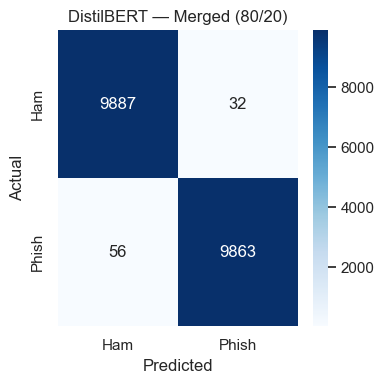

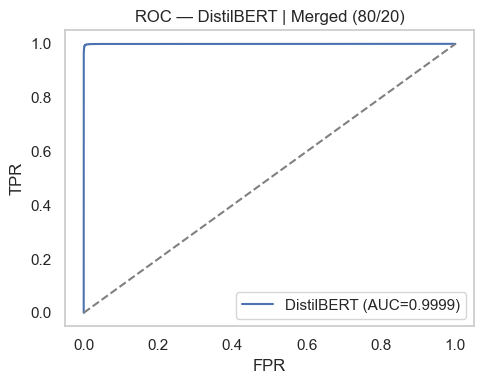

DistilBERT saved.


In [25]:
# ── DistilBERT Evaluation ──
print('\nEvaluating DistilBERT...')

bert_preds_out = trainer.predict(bert_te_ds)
bert_logits    = bert_preds_out.predictions
bert_true      = bert_preds_out.label_ids
bert_probs     = torch.softmax(torch.tensor(bert_logits), dim=1).numpy()[:, 1]
bert_pred_cls  = bert_logits.argmax(-1)

# Inference latency
n_samples = len(bert_te_ds)
t1 = time.time()
_ = trainer.predict(bert_te_ds)
bert_infer_time = (time.time() - t1) / n_samples

evaluate_model(
    'DistilBERT', bert_true, bert_pred_cls, bert_probs,
    dataset_name='Merged', split_name='80/20',
    train_time=bert_train_time, infer_time=bert_infer_time
)

# Save fine-tuned model
bert_model.save_pretrained(f'{MODELS_DIR}/distilbert_finetuned')
tokenizer.save_pretrained(f'{MODELS_DIR}/distilbert_finetuned')
print('DistilBERT saved.')

In [ ]:
if ckpt_done('distilbert_cross'):
    print(' [distilbert_cross] already done — skipping')
else:
    for train_name, train_df in dl_cross_pairs:
        # ── Cap rows — cross-eval doesn't need full dataset ──
        if len(train_df) > 5000:
            train_df = train_df.sample(5000, random_state=42).reset_index(drop=True)
            print(f'  Capped {train_name} to 5,000 rows for cross-eval')
        if len(train_df) < 50: continue

        tr_texts_b  = train_df['clean_text'].tolist()
        tr_labels_b = train_df['label'].astype(int).tolist()
        b_tr_ds = BertEmailDataset(tr_texts_b, tr_labels_b, tokenizer)

        b_model = DistilBertForSequenceClassification.from_pretrained(
            BERT_MODEL, num_labels=2)
        b_args = make_training_args(
            output_dir=f'{MODELS_DIR}/bert_cross_{train_name}',
            num_train_epochs=2,
            per_device_train_batch_size=BERT_BATCH,
            per_device_eval_batch_size=BERT_BATCH,
            learning_rate=BERT_LR,
            fp16=False,
            use_mps_device=torch.backends.mps.is_available(),
            evaluation_strategy='no',
            save_strategy='no',
            report_to='none',
            logging_steps=100,
        )
        b_trainer = Trainer(model=b_model, args=b_args, train_dataset=b_tr_ds)

        print(f'\nTraining DistilBERT on {train_name}...')
        t0 = time.time()
        b_trainer.train()
        b_train_time = time.time() - t0

        for test_name, test_df in dl_cross_pairs:
            if len(test_df) < 20: continue
            te_texts_b  = test_df['clean_text'].tolist()
            te_labels_b = test_df['label'].astype(int).tolist()
            b_te_ds  = BertEmailDataset(te_texts_b, te_labels_b, tokenizer)
            out      = b_trainer.predict(b_te_ds)
            t1       = time.time()
            _        = b_trainer.predict(b_te_ds)
            b_infer  = (time.time() - t1) / len(test_df)
            b_probs  = torch.softmax(torch.tensor(out.predictions), dim=1).numpy()[:, 1]
            b_preds  = out.predictions.argmax(-1)
            evaluate_model(
                'DistilBERT', out.label_ids, b_preds, b_probs,
                dataset_name=f'Train={train_name}→Test={test_name}',
                split_name='cross',
                train_time=b_train_time if test_name == train_name else None,
                infer_time=b_infer
            )

    print('\n DistilBERT cross-dataset evaluation complete.')
    ckpt_save('distilbert_cross', master_results=master_results)
    print(' DistilBERT cross-dataset complete and saved')


⏩  [distilbert_cross] already done — skipping


##  STEP 5: Master Comparison Table + Visualisations

In [27]:
# Save all results
results_df = pd.DataFrame(master_results)
results_df.to_csv(f'{RESULTS_DIR}/master_all_results.csv', index=False)

print('Total result rows:', len(results_df))
display(results_df.head(20))

Total result rows: 19


,model,dataset,split,accuracy,precision,recall,f1,roc_auc,train_time_s,infer_time_per_sample_s
0,LogisticRegression,Merged,80/20,0.986894,0.982998,0.990927,0.986946,0.998679,0.487833,1.729070e-07
1,RandomForest,Merged,80/20,0.987499,0.993670,0.981248,0.987420,0.999300,29.845579,3.713101e-05
2,XGBoost,Merged,80/20,0.978425,0.968137,0.989414,0.978660,0.997126,146.839992,3.367485e-06
3,LogisticRegression,Merged,70/30,0.985751,0.981351,0.990321,0.985816,0.998687,0.531446,1.085127e-07
4,RandomForest,Merged,70/30,0.984743,0.993297,0.976072,0.984609,0.999181,29.700459,4.951304e-05
5,XGBoost,Merged,70/30,0.977853,0.966840,0.989649,0.978111,0.996987,112.864211,2.579377e-06
6,LogisticRegression,Merged,60/40,0.984625,0.979548,0.989918,0.984706,0.998493,0.291181,9.272935e-08
7,RandomForest,Merged,60/40,0.984978,0.992980,0.976861,0.984855,0.999176,21.528673,4.005755e-05
8,XGBoost,Merged,60/40,0.976938,0.965784,0.988910,0.977210,0.996681,88.239225,2.451322e-06
9,LogisticRegression,Train=PhishTank→Test=Kaggle,cross,0.553758,0.967410,0.146734,0.254819,0.853317,NaN,1.576835e-07


In [28]:
# ── Summary Table: Best result per model (averaged over splits, Merged dataset) ──
core_models = ['LogisticRegression','RandomForest','XGBoost','CNN','LSTM','DistilBERT']

summary_rows = []
for model_name in core_models:
    sub = results_df[
        (results_df['model'] == model_name) &
        (results_df['dataset'] == 'Merged')
    ]
    if sub.empty: continue
    row = {
        'Model':     model_name,
        'Accuracy':  sub['accuracy'].mean(),
        'Precision': sub['precision'].mean(),
        'Recall':    sub['recall'].mean(),
        'F1':        sub['f1'].mean(),
        'ROC-AUC':   sub['roc_auc'].mean() if 'roc_auc' in sub.columns else None,
        'Avg Train Time (s)':   sub['train_time_s'].dropna().mean() if sub['train_time_s'].notna().any() else None,
        'Avg Infer (ms/sample)': sub['infer_time_per_sample_s'].dropna().mean() * 1000 if sub['infer_time_per_sample_s'].notna().any() else None,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n=== MASTER COMPARISON TABLE ===\n')
pd.set_option('display.float_format', '{:.4f}'.format)
display(summary_df)

summary_df.to_csv(f'{RESULTS_DIR}/master_comparison_table.csv')
print('\nSaved to:', f'{RESULTS_DIR}/master_comparison_table.csv')


=== MASTER COMPARISON TABLE ===



,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Train Time (s),Avg Infer (ms/sample)
Model,,,,,,,
LogisticRegression,0.9858,0.9813,0.9904,0.9858,0.9986,0.4368,0.0001
RandomForest,0.9857,0.9933,0.9781,0.9856,0.9992,27.0249,0.0422
XGBoost,0.9777,0.9669,0.9893,0.9780,0.9969,115.9811,0.0028
DistilBERT,0.9956,0.9968,0.9944,0.9956,0.9999,0.0000,10.0981



Saved to: /Users/rathodgopalkrishnabhimrao/LLM_Phishing_Project/results/master_comparison_table.csv


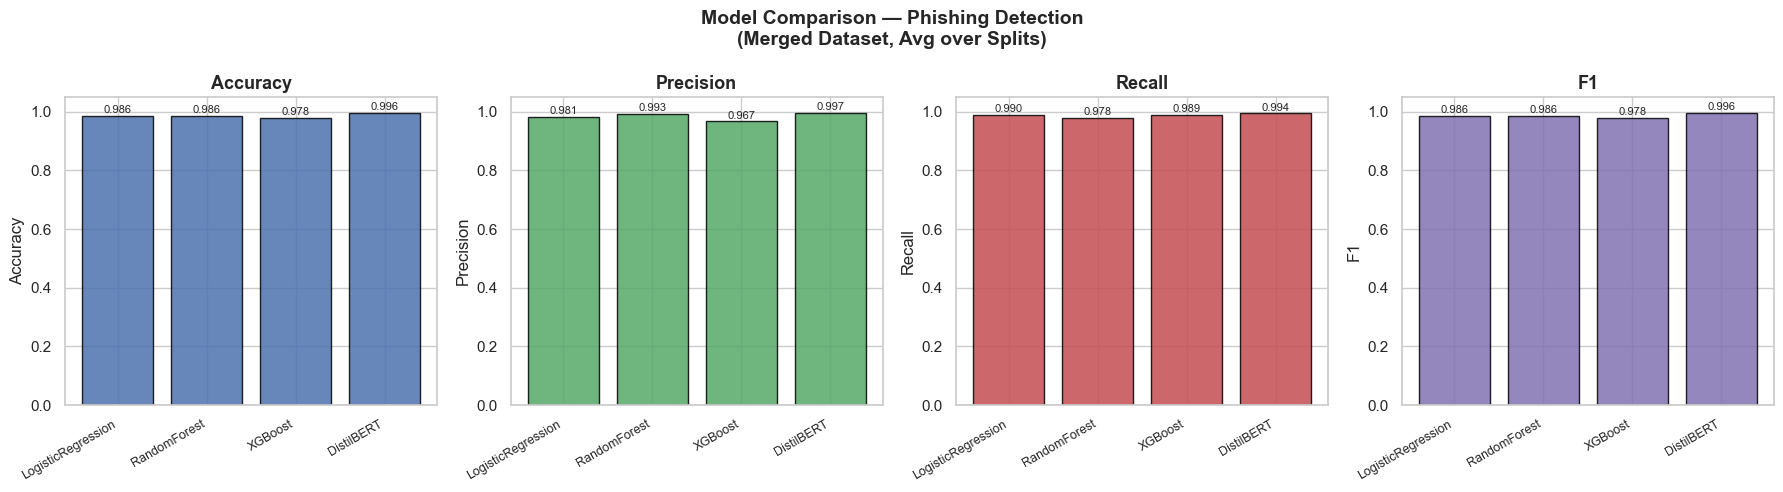

Comparison chart saved.


In [29]:
# ── Comparison Bar Chart: F1 Score ──
if not summary_df.empty:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    metrics = ['Accuracy','Precision','Recall','F1']
    colors  = ['#4C72B0','#55A868','#C44E52','#8172B2']

    for ax, metric, color in zip(axes, metrics, colors):
        vals = summary_df[metric].dropna()
        ax.bar(vals.index, vals.values, color=color, edgecolor='black', alpha=0.85)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(metric)
        ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=9)
        for i, v in enumerate(vals.values):
            ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

    fig.suptitle('Model Comparison — Phishing Detection\n(Merged Dataset, Avg over Splits)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/master_model_comparison.png', dpi=150)
    plt.show()
    print('Comparison chart saved.')

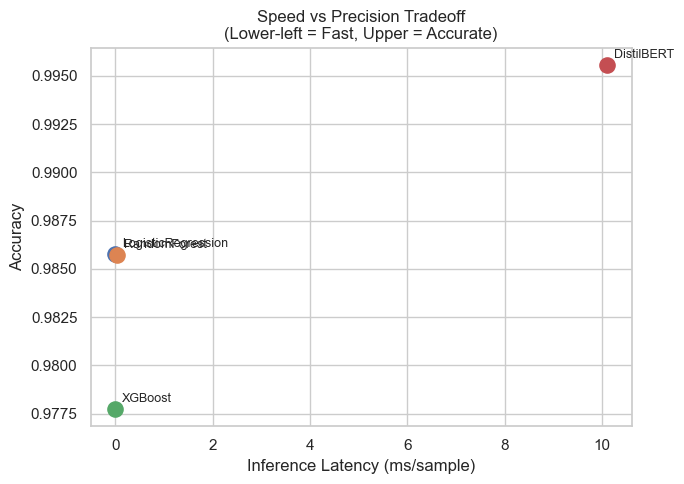

In [30]:
# ── Latency vs Accuracy scatter (Speed-Precision Tradeoff) ──
# This directly answers the research question about DistilBERT

latency_sub = summary_df[['Accuracy','Avg Infer (ms/sample)']].dropna()

if not latency_sub.empty:
    plt.figure(figsize=(7, 5))
    for model_name, row in latency_sub.iterrows():
        plt.scatter(row['Avg Infer (ms/sample)'], row['Accuracy'], s=120, zorder=5)
        plt.annotate(model_name,
                     xy=(row['Avg Infer (ms/sample)'], row['Accuracy']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    plt.xlabel('Inference Latency (ms/sample)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Speed vs Precision Tradeoff\n(Lower-left = Fast, Upper = Accurate)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/speed_precision_tradeoff.png', dpi=150)
    plt.show()

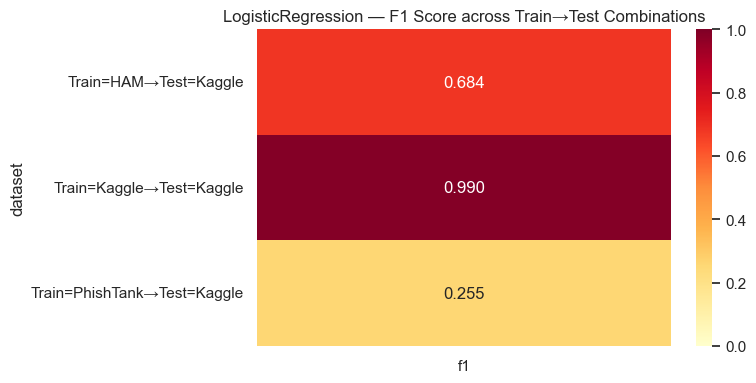

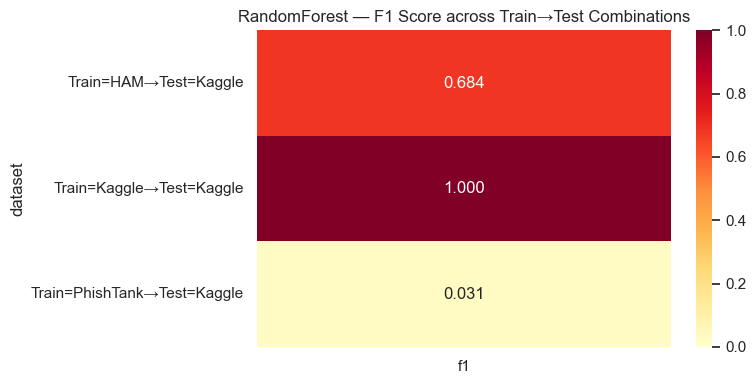

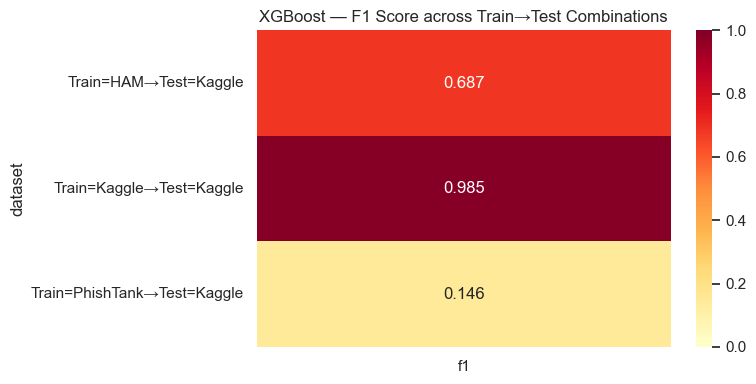

In [31]:
# ── Cross-dataset heatmap: F1 by Train→Test ──
cross_df = results_df[results_df['split'] == 'cross'].copy()

if not cross_df.empty:
    for mname in cross_df['model'].unique():
        sub = cross_df[cross_df['model'] == mname]
        try:
            pivot = sub.pivot_table(values='f1', index='dataset', aggfunc='mean')
            if pivot.shape[0] < 2: continue
            plt.figure(figsize=(8, 4))
            sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1)
            plt.title(f'{mname} — F1 Score across Train→Test Combinations')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_DIR}/cross_heatmap_{mname}.png', dpi=120)
            plt.show()
        except Exception as e:
            print(f'Heatmap skipped for {mname}: {e}')

## STEP 6: Suspicious Phrase Analysis & Feature Importance

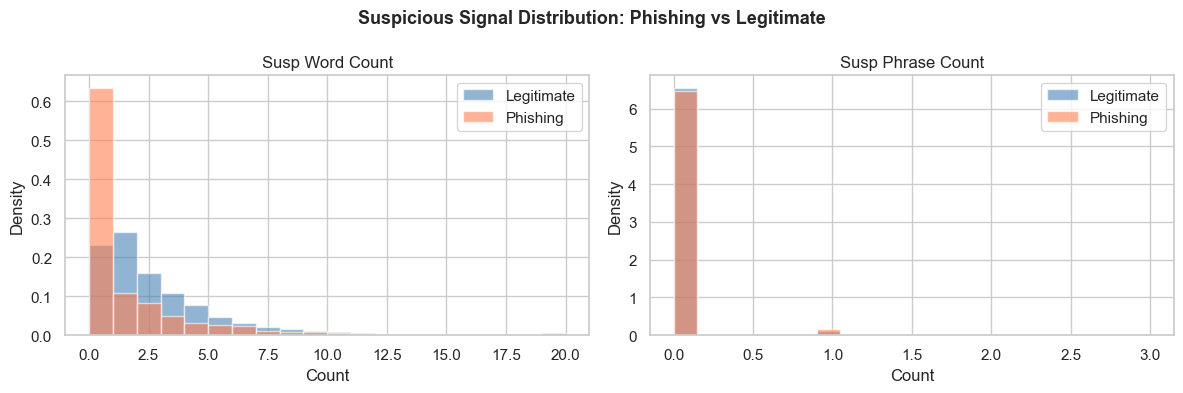


Mean suspicious counts by class:
      susp_word_count            susp_phrase_count           
                 mean median max              mean median max
label                                                        
0              2.4402 2.0000  46            0.0184 0.0000   3
1              1.2516 0.0000  31            0.0343 0.0000   3


In [32]:
# ── Suspicious signal distribution by class ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['susp_word_count', 'susp_phrase_count']):
    for label, color, lname in [(0,'steelblue','Legitimate'), (1,'coral','Phishing')]:
        subset = merged[merged.label == label][col]
        ax.hist(subset.clip(0, 20), bins=20, alpha=0.6, label=lname, color=color, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12)
    ax.set_xlabel('Count'); ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Suspicious Signal Distribution: Phishing vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/suspicious_signal_distribution.png', dpi=150)
plt.show()

# Statistical summary
print('\nMean suspicious counts by class:')
print(merged.groupby('label')[['susp_word_count','susp_phrase_count']].agg(['mean','median','max']))

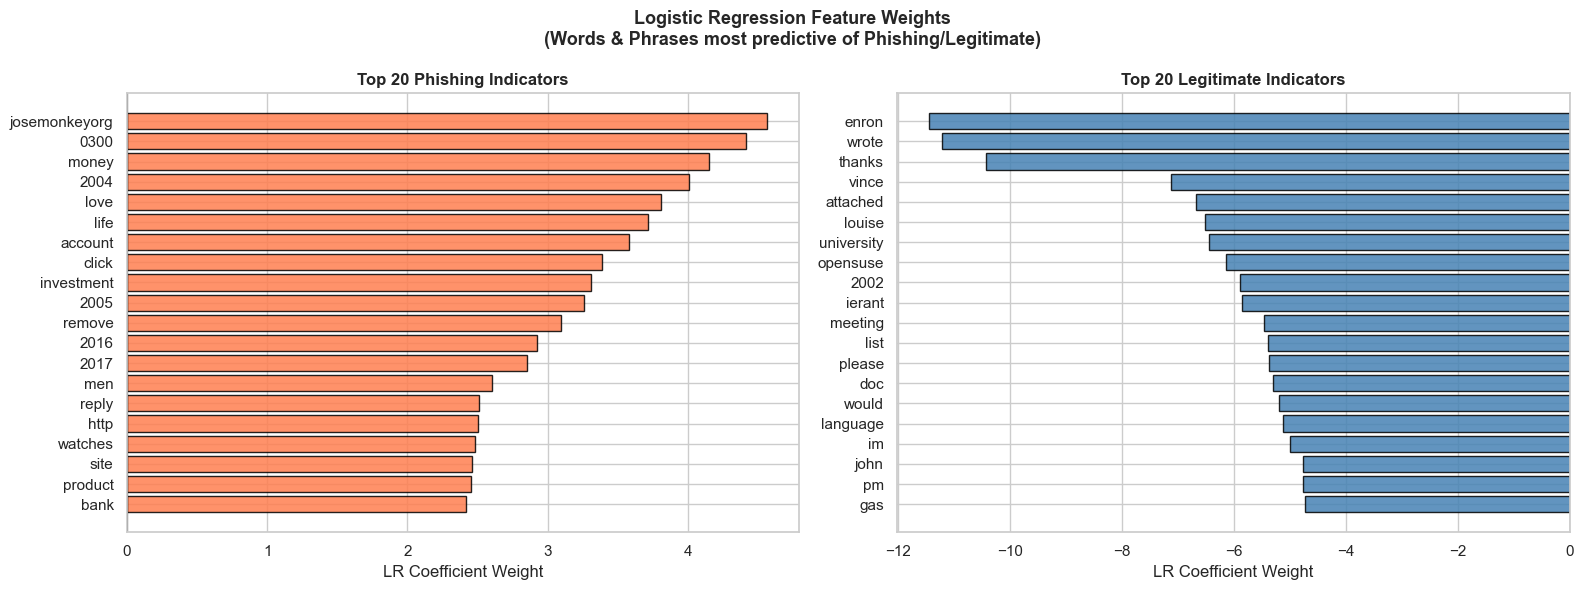

In [33]:
# ── Logistic Regression top feature weights ──
# Show which words/phrases the model finds most predictive

lr_trained = results_df[(results_df['model'] == 'LogisticRegression') & 
                         (results_df['split'] == '80/20') &
                         (results_df['dataset'] == 'Merged')]

# Re-train LR on full balanced set for feature extraction
lr_feat = LogisticRegression(max_iter=3000, C=1.0, random_state=RND)
lr_feat.fit(X_bal, y_bal)

feat_names = np.array(tfidf.get_feature_names_out())
coef = lr_feat.coef_[0]

# Top 20 phishing indicators + top 20 legitimate indicators
top_phish_idx = np.argsort(coef)[-20:][::-1]
top_ham_idx   = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idxs, title, color in [
    (axes[0], top_phish_idx, 'Top 20 Phishing Indicators', 'coral'),
    (axes[1], top_ham_idx,   'Top 20 Legitimate Indicators', 'steelblue'),
]:
    ax.barh(feat_names[idxs][::-1], coef[idxs][::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('LR Coefficient Weight')
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Logistic Regression Feature Weights\n(Words & Phrases most predictive of Phishing/Legitimate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/lr_feature_importance.png', dpi=150)
plt.show()

In [34]:
# ── Phrase-level phishing signal audit ──
# Show how many emails (by class) match each suspicious phrase pattern

phrase_stats = []
for i, pat in enumerate(SUSPICIOUS_PHRASES):
    phish_matches = merged[merged.label==1]['text'].astype(str).str.contains(pat, case=False, regex=True, na=False).sum()
    ham_matches   = merged[merged.label==0]['text'].astype(str).str.contains(pat, case=False, regex=True, na=False).sum()
    phrase_stats.append({
        'pattern': pat[:60]+'...' if len(pat) > 60 else pat,
        'phishing_matches': phish_matches,
        'ham_matches': ham_matches,
        'precision_signal': phish_matches / (phish_matches + ham_matches + 1e-6)
    })

phrase_df = pd.DataFrame(phrase_stats).sort_values('precision_signal', ascending=False)
print('\nTop 10 most discriminative phishing phrase patterns:')
display(phrase_df.head(10))

phrase_df.to_csv(f'{RESULTS_DIR}/phrase_signal_audit.csv', index=False)
print('Saved phrase audit.')


Top 10 most discriminative phishing phrase patterns:


,pattern,phishing_matches,ham_matches,precision_signal
1,unusual (activity|sign.?in|login|access) (dete...,4,0,1.0000
7,(act|respond|click|reply) (now|immediately|tod...,542,27,0.9525
21,(million|thousand) (dollar|pound|euro|usd),1384,95,0.9358
18,(transfer|wire) (of |)(\$|usd|eur|gbp|bitcoin),41,4,0.9111
20,(nigerian?|prince|princess|king|duke|diplomat)...,860,194,0.8159
8,(within|in the next) \d+ (hours|days|minutes),488,150,0.7649
2,unauthorized (access|login|sign.?in),13,6,0.6842
16,you (have |)(won|been selected|are the winner),1,1,0.5000
23,(virus|malware|trojan|ransomware) (detected|fo...,42,86,0.3281
9,(expires?|expiring) (in|on|soon),19,349,0.0516


Saved phrase audit.


## STEP 7: Save All Models & Final Summary

In [ ]:
# Save TF-IDF
joblib.dump(tfidf, f'{MODELS_DIR}/tfidf_vectorizer.joblib')

# Save word vocabulary for DL models
joblib.dump(word2idx, f'{MODELS_DIR}/word2idx.joblib')

# Save ML models (trained on full balanced data)
final_ml_models = get_ml_models()
for mname, m in final_ml_models.items():
    try:
        m.fit(X_bal, y_bal)
    except Exception:
        m.fit(X_bal.toarray(), y_bal)
    joblib.dump(m, f'{MODELS_DIR}/{mname}_model.joblib')
    print(f'Saved {mname}')

# Save DL models
torch.save(cnn_model.state_dict(),  f'{MODELS_DIR}/cnn_model.pt')
torch.save(lstm_model.state_dict(), f'{MODELS_DIR}/lstm_model.pt')

# DistilBERT already saved above

# Final results
results_df.to_csv(f'{RESULTS_DIR}/master_all_results.csv', index=False)
summary_df.to_csv(f'{RESULTS_DIR}/master_comparison_table.csv')

print('\n All models, vectorizers, and results saved!')
print(f'Output directory: {BASE_DIR}')
print('\nFiles saved:')
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        print(' ', os.path.join(root, f).replace(BASE_DIR, '').lstrip('/'))

Saved LogisticRegression
Saved RandomForest
Saved XGBoost

🎉 All models, vectorizers, and results saved!
Output directory: /Users/rathodgopalkrishnabhimrao/LLM_Phishing_Project

Files saved:
  .DS_Store
  finetuned/instruction_dataset.csv
  finetuned/.DS_Store
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/adapter_model.safetensors
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/rng_state.pth
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/tokenizer_config.json
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/special_tokens_map.json
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/optimizer.pt
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/scheduler.pt
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/tokenizer.json
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/tokenizer.model
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-500/README.md
  finetuned/TinyLlama_1.1B (CPU)_qlora_ckpt/checkpoint-

In [37]:
# ── Final Pretty Summary Table ──
print('\n' + '='*75)
print('  FINAL RESEARCH SUMMARY TABLE')
print('  LLM-Driven Phishing Email Detection Framework')
print('='*75)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

print(summary_df.to_string())
print('='*75)
print('\nML   → Baseline: LR, RF, XGB (TF-IDF features)')
print('DL   → Deep Learning progression: CNN → LSTM')
print('LLM  → DistilBERT fine-tuned (core innovation)')
print('\nKey findings:')
if not summary_df.empty:
    best_model = summary_df['F1'].idxmax()
    best_f1    = summary_df['F1'].max()
    fastest    = summary_df['Avg Infer (ms/sample)'].idxmin()
    print(f'  Best F1 score    : {best_model} ({best_f1:.4f})')
    print(f'  Fastest inference: {fastest}')
print('\n Complete. Results saved to Drive.')


  FINAL RESEARCH SUMMARY TABLE
  LLM-Driven Phishing Email Detection Framework
                    Accuracy  Precision  Recall     F1  ROC-AUC  Avg Train Time (s)  Avg Infer (ms/sample)
Model                                                                                                     
LogisticRegression    0.9858     0.9813  0.9904 0.9858   0.9986              0.4368                 0.0001
RandomForest          0.9857     0.9933  0.9781 0.9856   0.9992             27.0249                 0.0422
XGBoost               0.9777     0.9669  0.9893 0.9780   0.9969            115.9811                 0.0028
DistilBERT            0.9956     0.9968  0.9944 0.9956   0.9999              0.0000                10.0981

ML   → Baseline: LR, RF, XGB (TF-IDF features)
DL   → Deep Learning progression: CNN → LSTM
LLM  → DistilBERT fine-tuned (core innovation)

Key findings:
  Best F1 score    : DistilBERT (0.9956)
  Fastest inference: LogisticRegression

 Complete. Results saved to Drive.
